In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows (optional for exploration)
pd.set_option('display.max_rows', 100)
df = pd.read_csv("../data/raw/Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
# Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (255347, 18)


In [5]:
print(df.columns.tolist())

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [6]:
# Dataset Information
print("\nDataset Information:")
df.info()



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17 

In [7]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [15]:
# Check missing values
missing_values = df.isnull().sum()
print(missing_values)


LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [4]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 0


In [16]:
# Display data types
print(df.dtypes)


LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object


In [19]:
print(df["Default"].value_counts())

Default
0    225694
1     29653
Name: count, dtype: int64


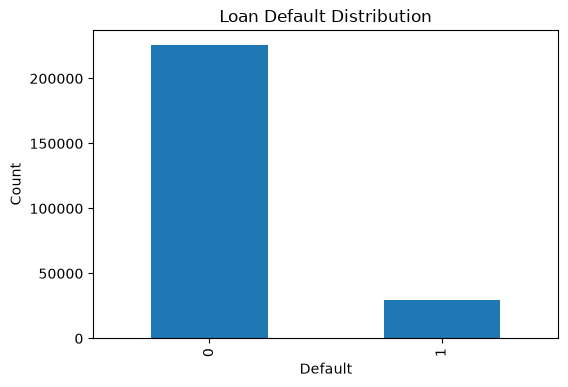

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["Default"].value_counts().plot(kind="bar")
plt.title("Loan Default Distribution")
plt.xlabel("Default")
plt.ylabel("Count")
plt.show()

In [22]:
numerical_cols=df.select_dtypes(include=["int64","float64"]).columns.tolist()

print("numerical columns:")
print(numerical_cols)

numerical columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']


In [23]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("categorical columns")
print(categorical_cols)


categorical columns
['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


C:\Users\deekshithvarala\AppData\Local\Temp\ipykernel_6760\1893701727.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [8]:
target = "Default"
print("Target Varable:",target)


Target Varable: Default


In [9]:
df = df.drop("LoanID",axis=1)
print("LoanID removed sucessfully")

LoanID removed sucessfully


In [10]:
print(df.columns)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='str')


In [11]:
# Display unique values in each categorical column

categorical_cols = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Education
<StringArray>
['Bachelor's', 'Master's', 'High School', 'PhD']
Length: 4, dtype: str

EmploymentType
<StringArray>
['Full-time', 'Unemployed', 'Self-employed', 'Part-time']
Length: 4, dtype: str

MaritalStatus
<StringArray>
['Divorced', 'Married', 'Single']
Length: 3, dtype: str

HasMortgage
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

HasDependents
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

LoanPurpose
<StringArray>
['Other', 'Auto', 'Business', 'Home', 'Education']
Length: 5, dtype: str

HasCoSigner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [12]:
# Convert Yes/No columns into 1/0

binary_cols = [
    "HasMortgage",
    "HasDependents",
    "HasCoSigner"
]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

print("Binary columns encoded successfully.")

Binary columns encoded successfully.


In [13]:
# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=[
        "Education",
        "EmploymentType",
        "MaritalStatus",
        "LoanPurpose"
    ],
    drop_first=True
)

print("One-Hot Encoding completed.")

One-Hot Encoding completed.


In [14]:

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,HasDependents,HasCoSigner,Default,Education_High School,Education_Master's,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,1,1,0,False,False,False,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,0,1,0,False,True,False,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,1,0,1,False,True,False,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,0,0,0,True,False,False,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,1,0,0,False,False,False,False,False,True,False,False,False,False,False,False


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   HasMortgage                   255347 non-null  int64  
 10  HasDependents                 255347 non-null  int64  
 11  HasCoSigner                   255347 non-null  int64  
 12  Default                       255347 non-null  int64  


In [16]:
# Convert boolean columns to integers

bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

print("Boolean columns converted to integers.")

Boolean columns converted to integers.


In [ ]:
import os
# Save processed dataset

os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/loan_default_processed.csv", index=False)

print("Processed dataset saved successfully!")

print("Processed dataset saved successfully!")

OSError: Cannot save file into a non-existent directory: '..\data\processed'